# Nuclear data uncertainty propagation using the SANDY API

This tutorial shows how to extract, process, and propagate nuclear data uncertainties using the SANDY Python library coupled with NJOY processing tools.

The workflow reflects a complete end‑to‑end path: from raw ENDF‑6 files to covariance sampling, to perturbation of evaluated data.

In [1]:
import sandy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

Note: NumExpr detected 12 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
NumExpr defaulting to 8 threads.


# Reading and Inspecting ENDF‑6 Data

We begin by retrieving the JEFF‑3.3 evaluated nuclear data file for hydrogen‑1 (ZAM=10010) from the [**IAEA archive**](https://www-nds.iaea.org/public/download-endf/).

Basic [**ENDF-6**](https://www.oecd-nea.org/dbdata/data/manual-endf/endf102.pdf) content inspection (MF=3, MT=1, etc.) allowed us to verify that the cross sections were available and correctly formatted.

> ZAM = Z $\times$ 10000 + A $\times$ 10 + M
> 
> - Z: charge number
> - A: mass number
> - M: metastate (0=ground state, 1=first metastate, ...)
> 
> For $^1$H, ZAM=10010
> 
> For $^{235}$U, ZAM=922350
> 
> For $^{242m}$Am, ZAM=952421

In [2]:
endf = sandy.get_endf6_file("jeff_33", "xs", 10010)

In [3]:
endf

MAT  MF  MT 
125  1   451     1.001000+3 9.991673-1          0          0  ...
     2   151     1.001000+3 9.991673-1          0          0  ...
     3   1       1.001000+3 9.991673-1          0          0  ...
         2       1.001000+3 9.991673-1          0          0  ...
         102     1.001000+3 9.991673-1          0          0  ...
     4   2       1.001000+3 9.991673-1          0          1  ...
     6   102     1.001000+3 9.991673-1          0          2  ...
     33  1       1.001000+3 9.991673-1          0          0  ...
         2       1.001000+3 9.991673-1          0          0  ...
         102     1.001000+3 9.991673-1          0          0  ...
dtype: object

In [4]:
print(endf.data[(125, 3, 1)])

 1.001000+3 9.991673-1          0          0          0          0 125 3  1    1
 0.000000+0 0.000000+0          0          0          2         96 125 3  1    2
         30          5         96          2                       125 3  1    3
 1.000000-5 3.713628+1 2.000000-5 3.224498+1 5.000000-5 2.790478+1 125 3  1    4
 1.000000-4 2.571732+1 2.000000-4 2.417056+1 5.000000-4 2.279806+1 125 3  1    5
 1.000000-3 2.210633+1 2.000000-3 2.161720+1 5.000000-3 2.118318+1 125 3  1    6
 1.000000-2 2.096443+1 2.530000-2 2.076834+1 5.000000-2 2.067250+1 125 3  1    7
 1.000000-1 2.060332+1 2.000000-1 2.055439+1 5.000000-1 2.051095+1 125 3  1    8
 1.000000+0 2.048901+1 2.000000+0 2.047341+1 5.000000+0 2.045928+1 125 3  1    9
 1.000000+1 2.045169+1 2.000000+1 2.044545+1 5.000000+1 2.043707+1 125 3  1   10
 1.000000+2 2.042815+1 2.000000+2 2.041317+1 5.000000+2 2.037161+1 125 3  1   11
 1.000000+3 2.030435+1 2.000000+3 2.017221+1 4.000000+3 1.991433+1 125 3  1   12
 6.000000+3 1.966407+1 8.000

In [6]:
endf.to_file("H1.jeff33")

# Extract cross section data

We reconstructed tabulated **pointwise cross sections** from resonance parameters.

This is done runnning the **RECONR** module of **NJOY**.

The output is a PENDF file, which contains:
 - Linearized cross sections
 - Reconstructed resonance region
 - Continuous energy grid

A 0.1% linearization tolerance (see parameter `err`) is used too speed-up calculations!

In [10]:
pendf = endf.get_pendf(err=0.1, verbose=True)

get_pendf | ZAM=10010 | augmented NJOY kwargs: { 'acer': False,
  'broadr': False,
  'broadr_kws': {'err': 0.1},
  'dryrun': False,
  'gaspr': False,
  'heatr': False,
  'purr': False,
  'reconr_kws': {'err': 0.1},
  'temperatures': [0],
  'thermr': False,
  'thermr_kws': {'err': 0.1},
  'unresr': False}
get_pendf | ZAM=10010 | run NJOY
_run_njoy | ZAM=10010 | NJOY ran in 1.183 s
get_pendf | ZAM=10010 | parsing NJOY PENDF output into Endf6 structure


Extract the cross sections from the PENDF file and plot them to provide an overview of the $\sigma(E)$ behavior for several MT reactions.

In [11]:
xs = sandy.Xs.from_endf6(pendf)

<Axes: xlabel='E'>

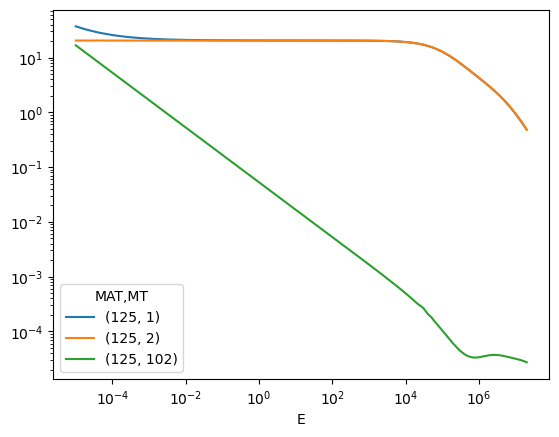

In [12]:
xs.data.plot(logx=True, logy=True)

# Extract covariance data

Covariance data are contained in the ENDF-6 file, but they must be processed to:
- have a unique multi-group structure for all reactions
- reconstruct covariance data when partial contributions are given, e.g., background uncertainty + other uncertainties
- impose constraints if given (total = $\sum$partial)

This is done with **NJOY** (module **ERRORR**) and requires:
- group structure (see parameter `ign`)
- approximate neutron spectrum (see parameter `iwt`)

The output is a ERRORR file.

In [7]:
errorrs = endf.get_errorr(verbose=True, err=0.1, errorr33_kws=dict(ign=4))

get_errorr | ZAM=10010 | loaded ENDF records: MF present = [ 1  2  3  4  6 33]
get_errorr | ZAM=10010 | augmenting ERRORR NJOY kwargs
get_errorr | ZAM=10010 | augmenting GROUPR NJOY kwargs
get_errorr | ZAM=10010 | covariance availability: MF31=False MF33=True MF34=False MF35=False
get_errorr | ZAM=10010 | covariance processing: MF31=False MF33=True MF34=False MF35=False
get_errorr | ZAM=10010 | running NJOY with augmented kwargs: { 'acer': False,
  'broadr': False,
  'broadr_kws': {'err': 0.1},
  'dryrun': False,
  'errorr31': False,
  'errorr31_kws': {},
  'errorr33': True,
  'errorr33_kws': {'ign': 4},
  'errorr34': False,
  'errorr34_kws': {},
  'errorr35': False,
  'errorr35_kws': {},
  'gaspr': False,
  'groupr_kws': {'chi': False, 'mubar': True, 'nubar': False},
  'heatr': False,
  'purr': False,
  'reconr_kws': {'err': 0.1},
  'temperatures': [0],
  'thermr': False,
  'thermr_kws': {'err': 0.1},
  'unresr': False}
get_errorr | ZAM=10010 | run NJOY
_run_njoy | ZAM=10010 | NJOY ra

Then, extract the covariance matrix from the ERRORR file.

In [8]:
cov = errorrs["errorr33"].get_cov()

## Plot the multigroup energy structure of the covariance matrix

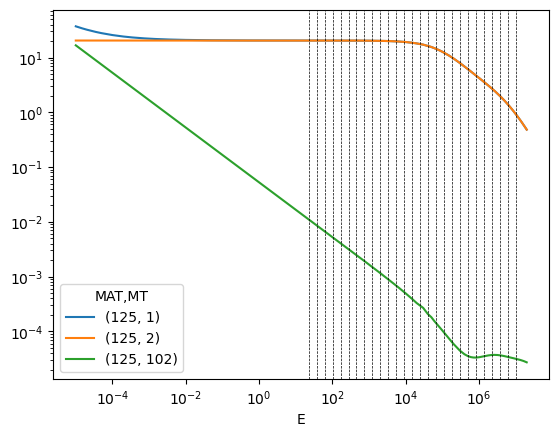

In [13]:
xs.data.plot(logx=True, logy=True)
plt.vlines(cov.data.index.get_level_values("E").right.unique(), ymin=0, ymax=100, color="k", ls="--", lw=.5)

## Plot the correlation matrix

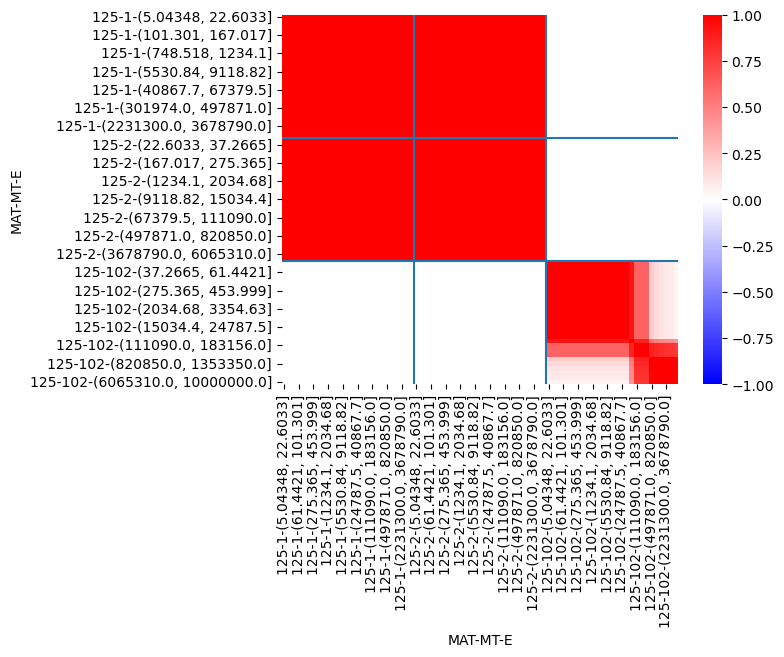

In [14]:
sns.heatmap(data=cov.get_corr().data, vmin=-1, vmax=1, cmap="bwr")
plt.axvline(27)
plt.axhline(27)
plt.axvline(27 * 2)
plt.axhline(27 * 2)

## Plot the standard deviation

<Axes: >

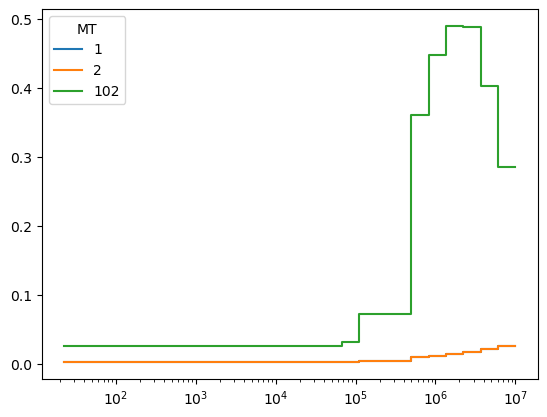

In [15]:
std = cov.get_std().reset_index().pivot_table(index="E", columns="MT", values="STD")
std.index = std.index.right
std.plot(drawstyle="steps-pre", logx=True)

# Draw sample of PDF with given covariance matrix

Nuclear data covariance matrices are in relative terms (divide by the mean). Then the PDF is centered in one.

Random variable: $\frac{X}{E[X]}$

Mean value: $E\left[\frac{X}{E[X]}\right]=1$

Variance: $Var\left(\frac{X}{E[X]}\right) = E\left[\left(\frac{X}{E[X]}-1\right)^2\right] = E\left[\left(\frac{X-E[X]}{E[X]}\right)^2\right] = \frac{E\left[\left(X-E[X]\right)^2\right]}{E[X]^2}=\frac{Var(X)}{E[X]^2} \; \xRightarrow{\sqrt{}} \; \frac{\sigma_X}{\mu_X}$

Take a sample of size $N=10000$. Make it reproducible by fixing the seed.

In [16]:
smp = cov.sampling(10000, seed=1)

## Plot the sample estimate of the correlation matrix

In this step, we compute the sample correlation matrix for the dataset and visualize it using a heatmap.

The matrix `scorr` contains the pairwise correlations between all features in the sample.

In [56]:
scorr = smp.get_corr()

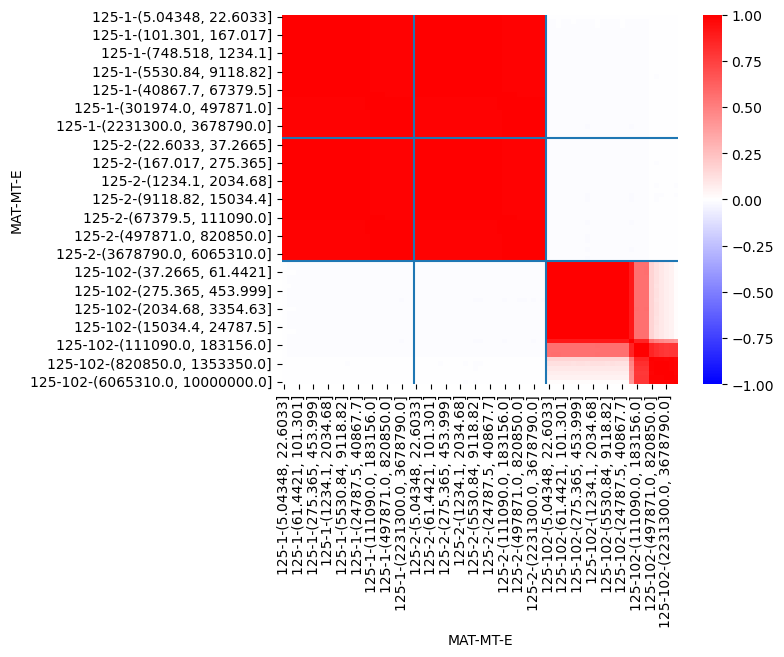

In [57]:
sns.heatmap(scorr, vmin=-1, vmax=1, cmap='bwr')
plt.axvline(27)
plt.axhline(27)
plt.axvline(27 * 2)
plt.axhline(27 * 2)

Values range from `-1` (perfect negative correlation) to `+1` (perfect positive correlation).

The colormap `'bwr'` (blue‑white‑red) helps interpret correlations visually:

 - 🔵 Blue → strong negative correlation
 - ⚪ White → no correlation
 - 🔴 Red → strong positive correlation

## Plot the sample estimate of the standard deviation

Compute the **sample standard deviation** for each reaction and visualize how this sample‑based estimate compares to the true or reference standard deviation.

The sample estimate can be computed over different samples sizes by changing this parameter.

In [63]:
selected_sample_size = 10000

<Axes: >

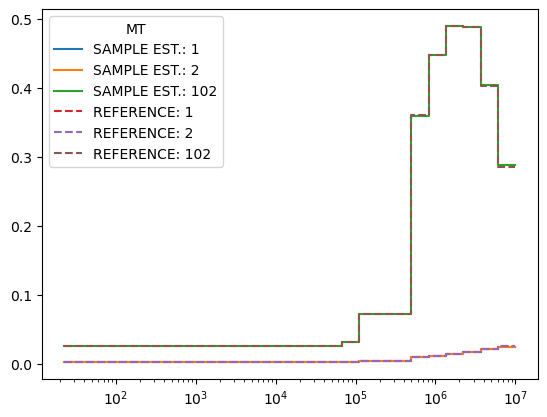

In [77]:
# plot sample estimate
sstd = smp.data.iloc[:, :selected_sample_size].std(axis=1).rename("STD").reset_index().pivot_table(index="E", columns="MT", values="STD")
sstd.index = sstd.index.right
ax = sstd.add_prefix("SAMPLE EST.: ").plot(drawstyle="steps-pre", logx=True)

# plot reference standard deviation
std.add_prefix("REFERENCE: ").plot(drawstyle="steps-pre", ls="--", logx=True, ax=ax)

## Plot the sample estimate of the PDF

We estimate the probability density function (PDF) of a selected subset of the data by plotting a histogram.

- We select a specific reaction.

In [94]:
mt = 102

- And we keep only one energy group, for instance the third-to-last values.

In [95]:
group = -3

The last groups have a larger standard deviation.

In [93]:
smp.data.query("MT==@mt").std(axis=1)

MAT  MT   E                      
125  102  (5.04348, 22.6033]         0.025287
          (22.6033, 37.2665]         0.025262
          (37.2665, 61.4421]         0.025297
          (61.4421, 101.301]         0.025285
          (101.301, 167.017]         0.025259
          (167.017, 275.365]         0.025304
          (275.365, 453.999]         0.025276
          (453.999, 748.518]         0.025284
          (748.518, 1234.1]          0.025271
          (1234.1, 2034.68]          0.025279
          (2034.68, 3354.63]         0.025265
          (3354.63, 5530.84]         0.025288
          (5530.84, 9118.82]         0.025311
          (9118.82, 15034.4]         0.025273
          (15034.4, 24787.5]         0.025254
          (24787.5, 40867.7]         0.025265
          (40867.7, 67379.5]         0.025297
          (67379.5, 111090.0]        0.031696
          (111090.0, 183156.0]       0.072916
          (183156.0, 301974.0]       0.073046
          (301974.0, 497871.0]       0.072943


The resulting histogram visualizes the sample estimates of the distribution.

<Axes: xlabel='vals', ylabel='Count'>

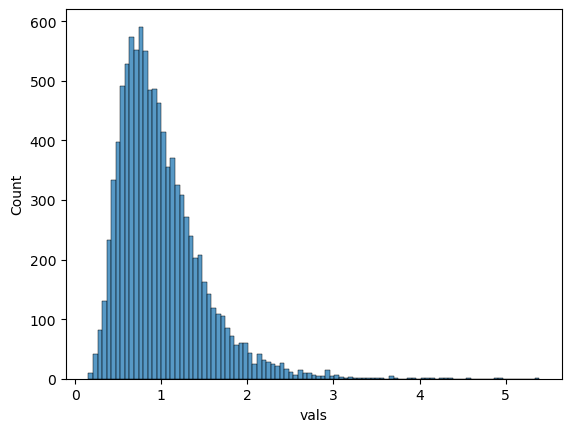

In [99]:
sns.histplot(smp.data.query("MT==@mt").stack().rename("vals").reset_index().groupby(["SMP"]).nth(group), x="vals")

# Multi-group perturbation vs continuous energy data

Here we compare the **multi‑group perturbation** coefficients with the resulting effect on the **continuous‑energy cross section**.

We begin by choosing a sample index (`which_sample = 5`). Changing this parameter allows you to examine the perturbation coefficients of a different sample.

In [145]:
which_sample = 5

The perturbation values for the chosen sample are extracted from the sample matrix and reshaped into the same structure as the cross‑section object:

- rows indexed by the energy grid E
- columns defined by (MAT, MT)

This alignment is necessary so that the perturbations can be applied element‑wise to the continuous‑energy cross section.

In [146]:
s = smp.data[which_sample].reset_index().pivot_table(index="E", columns=["MAT", "MT"], values=which_sample)
s

MAT                           125                    
MT                            1         2         102
E                                                    
(5.04348, 22.6033]       1.003639  1.003386  0.979453
(22.6033, 37.2665]       1.003201  1.003198  0.979838
(37.2665, 61.4421]       1.003159  1.003415  0.980720
(61.4421, 101.301]       1.003339  1.002977  0.980540
(101.301, 167.017]       1.003276  1.003582  0.980849
(167.017, 275.365]       1.003357  1.003292  0.980496
(275.365, 453.999]       1.002899  1.003283  0.981418
(453.999, 748.518]       1.003848  1.003512  0.981398
(748.518, 1234.1]        1.003963  1.003124  0.979822
(1234.1, 2034.68]        1.002939  1.003284  0.977166
(2034.68, 3354.63]       1.003335  1.002962  0.980751
(3354.63, 5530.84]       1.003192  1.003294  0.978052
(5530.84, 9118.82]       1.003520  1.003269  0.981612
(9118.82, 15034.4]       1.003415  1.003563  0.979664
(15034.4, 24787.5]       1.003269  1.003387  0.976907
(24787.5, 40867.7]       1.003159  1.002948  0.978715
(40867.7, 67379.5]       1.003307  1.003210  0.978347
(67379.5, 111090.0]      1.004208  1.003893  0.982832
(111090.0, 183156.0]     1.005641  1.005601  0.984088
(183156.0, 301974.0]     1.006172  1.005536  0.982423
(301974.0, 497871.0]     1.005745  1.005372  0.989591
(497871.0, 820850.0]     1.011286  1.010742  1.075059
(820850.0, 1353350.0]    1.015137  1.014220  1.078522
(1353350.0, 2231300.0]   1.016674  1.016757  1.095707
(2231300.0, 3678790.0]   1.022819  1.024526  1.094287
(3678790.0, 6065310.0]   1.026724  1.024842  1.147751
(6065310.0, 10000000.0]  1.031258  1.031993  1.169550

The operator

In [147]:
xs0 = xs._perturb(s)

produces a new continuous‑energy cross section where each point has been scaled according to the multi‑group coefficient in its energy bin.

To understand the local effect of the perturbation, we compute the pointwise ratio

In [148]:
mt = 102
ratio = (xs0.data / xs.data)[125, mt].rename("RATIO").reset_index()

for a specific reaction channel (MT = 102), resulting in a continuous‑energy curve showing how much each point increased or decreased.

Now we plot the comparison. We overlay:

- the multi‑group perturbation coefficients (a step function),
- the energy group boundaries, and
- the continuous‑energy ratio

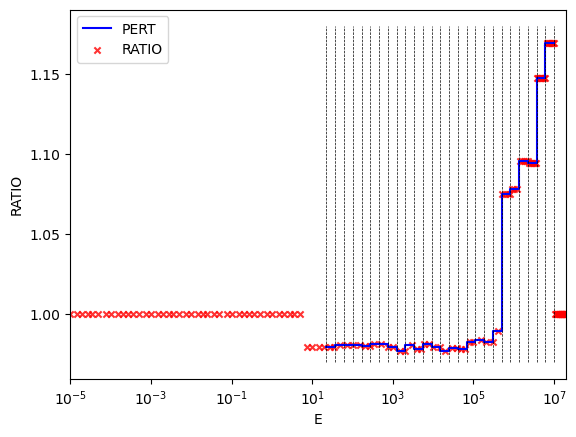

In [152]:
fig, ax = plt.subplots()

ax.plot(s.index.right, s[(125, 102)], drawstyle="steps-pre", label="PERT", color="b")
ax.vlines(cov.data.index.get_level_values("E").right.unique(), ymin=0.97, ymax=1.18, color="k", ls="--", lw=.5)

ratio.plot.scatter(x="E", y="RATIO", logx=True, label="RATIO", ax=ax, color="r", marker="x", alpha=.8)

plt.xscale("log")
plt.xlim(1e-5, 2e7)
plt.legend()

Every cross‑section point lying inside the same multi‑group energy bin is multiplied by the **same perturbation coefficient**.

The continuous‑energy ratio curve therefore follows the step‑wise multi‑group structure, but with fine‑scale fluctuations inherited from the original pointwise cross section.

# Analyze convergence

When working with a sequence of data points $x_1, x_2, \dots, x_n$, it can be useful to see how statistical measures evolve as more data is added.

This is exactly what the running mean and running standard deviation show.

**Running mean**

The running mean (also called the **cumulative mean**) at position $i$ is the mean of the first $i$ values:

$$
\mathrm{running\;mean}(i) = \frac{1}{i} \sum_{k=1}^i x_k
$$

This tells you:

- how the average changes as new observations come in
- how quickly the average stabilizes
- whether early values dominate or later values pull the mean in a new direction

If the dataset is stable, the running mean will gradually converge to the final mean.

**Running standard deviation**

It measures how spread out the first $i$ data points are, i.e.,

$$
\mathrm{running\;std}(i) = \sqrt{ \frac{1}{i-1} \sum_{k=1}^i \left( x_k - \mathrm{running\;mean(i)} \right)^2 }
$$

This helps you see:

- how the variability changes as more data arrives
- whether the distribution initially appears noisy but stabilizes over time
- how many samples are needed before the standard deviation becomes reliable

Like the running mean, the running standard deviation typically becomes more stable as the sample size increases.

Here we compute and visualize how the running mean and running standard deviation evolve for a selected parameter:

In [48]:
idx = 0
x = smp.data.iloc[idx]
running_mean = pd.Series({i: np.mean(x[:i]) for i in range(1, len(x)+1)})
running_std = pd.Series({i: np.std(x[:i]) for i in range(1, len(x)+1)})

Both running statistics are then normalized by dividing by their final value.
This allows comparing their relative convergence behavior on the same scale.

This helps illustrate how statistical estimators (mean, std) converge as sample size increases.

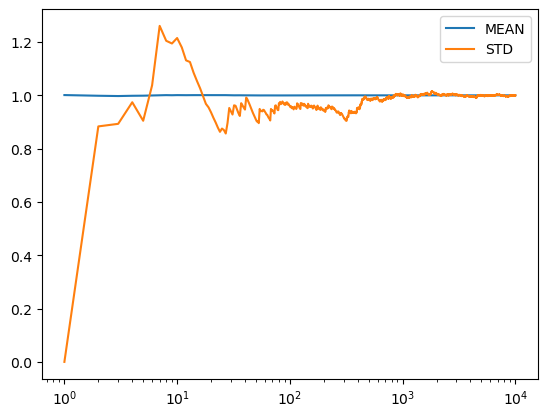

In [49]:
(running_mean / running_mean.iloc[-1]).plot(label="MEAN", logx=True)
(running_std / running_std.iloc[-1]).plot(label="STD", logx=True)
plt.legend()

Running statistics show convergence behavior:

- With few data points: both mean and std fluctuate a lot.
- With more data: they settle toward their “true” values.

Plotting them (especially on a log x‑scale) helps visualize how fast these estimates stabilize.

# Wrap it up in two steps

Create a sample (size $N=20$) from the multi-group relative covariance matrix of $^1$H cross sections. Then store these perturbations in a excel file.

In [28]:
smps = endf.get_perturbations(20, verbose=True)

########################################################
                GET PERTURBATIONS                       
########################################################
get_perturbations_xs | ZAM=10010 | run ERRORR via get_errorr({'mubar': False, 'njoy_output': -3})
get_perturbations_xs | ZAM=10010 | covariance MFs available=[33]
get_perturbations_xs | ZAM=10010 | MF=33 | writing ERRORR -> 'C:\Users\lfiorito\sandy_workshop\Exercises\CASE2\ERRORR_1001_MF33.tape'
get_perturbations_xs | ZAM=10010 | MF=33 | extracting covariance matrix
get_perturbations_xs | ZAM=10010 | MF=33 | covariance matrix size=(720, 720)
get_perturbations_xs | ZAM=10010 | MF=33 | found MT numbers=[  1   2 102]
get_perturbations_xs | ZAM=10010 | MF=33 | explicit seed not provided
get_perturbations_xs | ZAM=10010 | MF=33 | sampling with SMP size=20 via sampling(seed=258253628051918319046329564000497298079, {})
get_perturbations_xs | ZAM=10010 | MF=33 | writing samples -> 'C:\Users\lfiorito\sandy_workshop\Exercises\C

Convert the multi-group perturbations into random ENDF-6 files.

In [29]:
outs = endf.apply_perturbations(smps, to_file=True, verbose=True)

########################################################
              APPLY PERTURBATIONS                       
########################################################
apply_perturbations_xs | ZAM=10010 | kinds={33} | SMP size=20
apply_perturbations_xs | ZAM=10010 | PENDF=generated via get_pendf({'njoy_output': -3})
apply_perturbations_xs | ZAM=10010 | mode=serial


XS perturbations:   0%|                                                                             | 0/20 [00…

[PID 13156] XS-worker | sample=   0 | ZAM=10010 | (NU=False, XS=True, PFNS=False) | start
[PID 13156] XS-worker | sample=   0 | ZAM=10010 | writing to file
[PID 13156] WRITE-worker | sample=   0 | ZAM=10010 | writing ENDF-6 to file -> '1001_0.endf6'
[PID 13156] WRITE-worker | sample=   0 | ZAM=10010 | Writing PENDF to file -> '1001_0.pendf'
[PID 13156] XS-worker | sample=   0 | ZAM=10010 | finished in 0.176 s
[PID 13156] XS-worker | sample=   1 | ZAM=10010 | (NU=False, XS=True, PFNS=False) | start
[PID 13156] XS-worker | sample=   1 | ZAM=10010 | writing to file
[PID 13156] WRITE-worker | sample=   1 | ZAM=10010 | writing ENDF-6 to file -> '1001_1.endf6'
[PID 13156] WRITE-worker | sample=   1 | ZAM=10010 | Writing PENDF to file -> '1001_1.pendf'
[PID 13156] XS-worker | sample=   1 | ZAM=10010 | finished in 0.165 s
[PID 13156] XS-worker | sample=   2 | ZAM=10010 | (NU=False, XS=True, PFNS=False) | start
[PID 13156] XS-worker | sample=   2 | ZAM=10010 | writing to file
[PID 13156] WRITE-